### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\

    u &= g_D \qquad             &\text{on } \Gamma_D\\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is assumed piecewise smooth. The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ then translate to 

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*}
$$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [3]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=±1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

In [4]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    
    res_1 = k(pde_in) * grad_u + v
    
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y
    
    return res_1, res_2

In [5]:
def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).to(torch.float16).unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0),
    last_layer_activation='disc',
    disc_steepness=10.0 
)

model_ctx_v = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0),
    last_layer_activation='disc',
    disc_steepness=10.0
)



model_u = mm.MLPModel(model_ctx_u).to(device)
optim_u = torch.optim.Adam(model_u.parameters(), lr=1e-3)
scheduler_u = ReduceLROnPlateau(optim_u, factor=0.75, patience=3_000)

model_v = mm.MLPModel(model_ctx_v).to(device)
#model_v.load_state_dict(model_u.state_dict())
optim_v = torch.optim.Adam(model_v.parameters(), lr=1e-3)
scheduler_v = ReduceLROnPlateau(optim_v, factor=0.75, patience=3_000)

In [6]:
def g0_combined(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([g_D(x), h(x)], dim=1)   # (N,1) | (N,2)  →  (N,3)

def g1_combined(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([u_0(x), v_0(x)], dim=1)  # (N,1) | (N,2)  →  (N,3)

# ── Build the combined model ──────────────────────────────────────────────
combined_ctx = ed.DiscModelCtx(
    input_dim=2,
    output_dims=[1, 2],                      # expert 0 → u (1D), expert 1 → v (2D)
    hidden_layers_per_output=[
        [50, 50, 50, 50],                        # hidden widths for u-expert
        [50, 50, 50, 50],                        # hidden widths for v-expert
    ],
    discontinuous_per_layer=[False, True],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    normalize_inputt=True,
    hard_enforce=True,
    constraint_functions=(g0_combined, g1_combined),
)

model_combined = ed.DiscontinousModel(combined_ctx).to(device)
optim_combine = torch.optim.Adam(model_combined.parameters(), lr=1e-4)
scheduler_combine = ReduceLROnPlateau(optim_combine, factor=0.75, patience=3_000)

In [7]:

def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)

    loss_1 = torch.mean(res_1[:, 0]**2 + res_1[:, 1]**2)
    loss_2 = torch.mean(res_2**2)

    return [10*loss_1, loss_2]

In [8]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f"Interior points: {domain.interior.shape}")

Interior points: torch.Size([10000, 2])


In [9]:
# train_ctx_u = train.TrainingContext(
#     model=model_u,
#     domain=domain,
#     optimizer=optim_u,
#     loss_fn=pre_loss_u,
#     epochs=5_000,
#     monitor_gradient=True,
#     monitor_lr=True,
#     scheduler=scheduler_u,
# )

# train_ctx_v = train.TrainingContext(
#     model=model_v,
#     domain=domain,
#     optimizer=optim_v,
#     loss_fn=pre_loss_v,
#     epochs=5_000,
#     monitor_gradient=True,
    
#     monitor_lr=True,
#     scheduler=scheduler_v
# )

# CYCLES = 300

# v_loss = []
# u_loss = []
# v_loss_comp = [[], []]

# print("PRETRAINING")

# _, _ = train.simple_train(train_ctx_u)
# _, _ = train.simple_train(train_ctx_v)

# print("\n\nENDED PRETRAINING\n\n")

# train_ctx_u.epochs = 200
# train_ctx_v.epochs = 200
# train_ctx_u.loss_fn = loss_u
# train_ctx_v.loss_fn = loss_v
# for cycle in range(CYCLES):
#     print(f"Starting cycle {cycle}/{CYCLES}")
#     print("Training v, holding u const...")
#     model_u.eval()
#     model_v.train()
#    # _, _ = train.train_switch_to_lbfgs(train_ctx_v, epochs_with_lbfgs=300, lbfgs_lr=0.1)
#     v_loss_temp, v_comp_loss_temp = train.simple_train(train_ctx_v)
#     print("Training u, holding v const...")
#     model_v.eval()
#     model_u.train()
#    # _, _ = train.train_switch_to_lbfgs(train_ctx_u, epochs_with_lbfgs=300, lbfgs_lr=0.1)
#     u_loss_temp, _ = train.simple_train(train_ctx_u)
    
#     v_loss += v_loss_temp
#     u_loss += u_loss_temp
    
#     v_loss_comp[0] += v_comp_loss_temp[0]
#     v_loss_comp[1] += v_comp_loss_temp[1]
    

# print("Switching to LBFGS cycles")

In [10]:
train_ctx_combined = train.TrainingContext(
    model=model_combined,
    domain=domain,
    optimizer=optim_combine,
    loss_fn=loss_combined,
    epochs=60_000,
    monitor_gradient=True,
    monitor_lr=True,
    scheduler=scheduler_combine,
)

combined_loss, combined_loss_comps = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1)

Loss at epoch 1 is: 13.943061828613281. Total gradient norm: nan Current learing rate: 0.0001 
Loss at epoch 100 is: 4.3235063552856445. Total gradient norm: 9.456513218615983 Current learing rate: 0.0001 
Loss at epoch 200 is: 2.1299681663513184. Total gradient norm: 1.393033577930449 Current learing rate: 0.0001 
Loss at epoch 300 is: 1.7889693975448608. Total gradient norm: 1.4621542784397006 Current learing rate: 0.0001 
Loss at epoch 400 is: 1.5194547176361084. Total gradient norm: 1.3101924645222922 Current learing rate: 0.0001 
Loss at epoch 500 is: 1.3654744625091553. Total gradient norm: 1.1852979698586648 Current learing rate: 0.0001 
Loss at epoch 600 is: 1.1405333280563354. Total gradient norm: 1.0851247483369248 Current learing rate: 0.0001 
Loss at epoch 700 is: 0.9709962010383606. Total gradient norm: 1.0265957740509857 Current learing rate: 0.0001 
Loss at epoch 800 is: 0.8411335349082947. Total gradient norm: 0.7702087583947738 Current learing rate: 0.0001 
Loss at epo

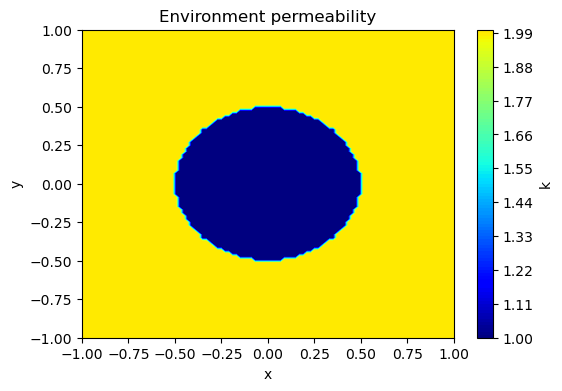

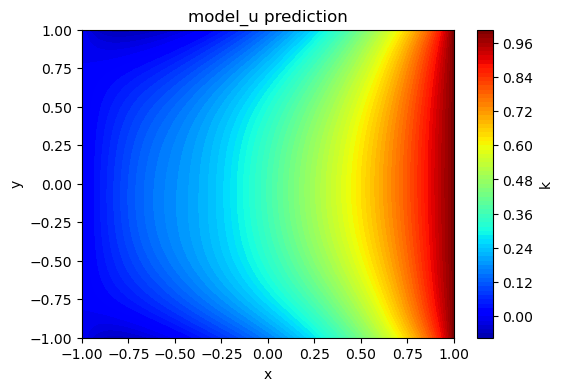

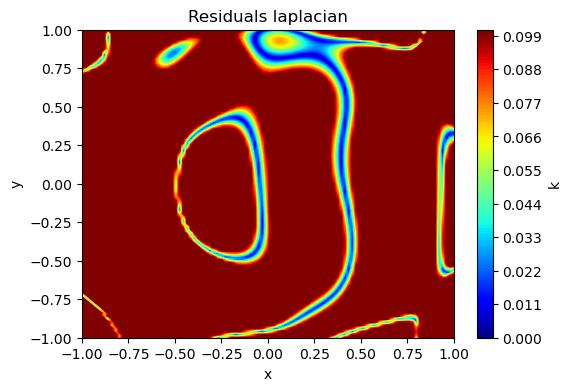

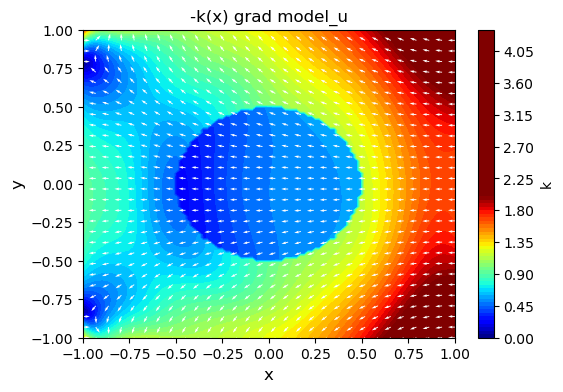

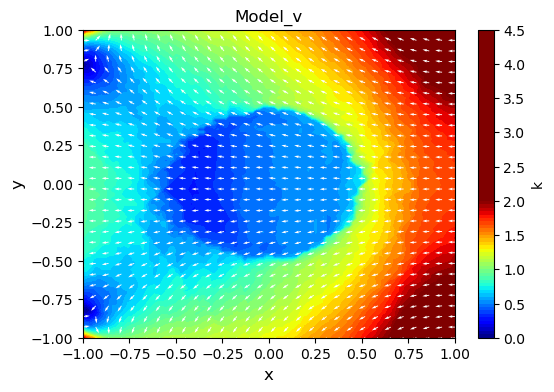

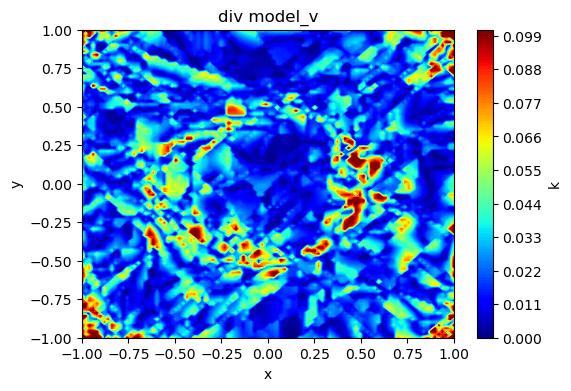

In [16]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)[:, 0]
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_grad = u_grad
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]
    
    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    return (u_xx + u_yy)

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=1,
    vmax=2.5,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmin = -0.12
plot_ctx.vmax = 1

plot_ctx.titles = ['model_u prediction']

utils.plot_function_on_2d_cube([lambda x: model_combined(x)[:, 0]], plot_ctx)

plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0
plot_ctx.titles = ["Residuals laplacian"]

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined)), 0.0, 0.1)], plot_ctx)

plot_ctx.vmin = 0
plot_ctx.vmax = 2

plot_ctx.titles = ['-k(x) grad model_u']

def heat_flow(x):
    x.requires_grad_(True)
    u = model_combined(x)[:, 0]
    
    return - k(x) * grad(u, x, torch.ones_like(u))[0]

utils.plot_vector_field_2d([lambda x: heat_flow(x)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['Model_v']
utils.plot_vector_field_2d([lambda x:  model_combined(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0
plot_ctx.titles = ["Residuals trained"]

def res_plot_help(x):
    x.requires_grad_(True)
    out = model_combined(x)
    u = out[:, 0]
    v = out[:, 1:]
    
    res_1, res_2 = res(u, v, x)
        
    return res_2 #torch.norm(res_1, dim=1, p=2)

plot_ctx.titles = ["div model_v"]
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_plot_help(x)), 0.0, 0.1)], plot_ctx)

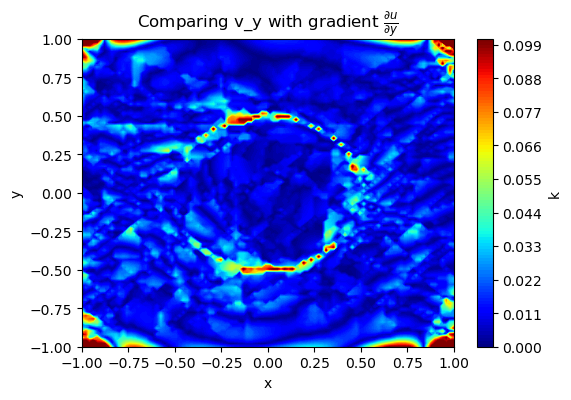

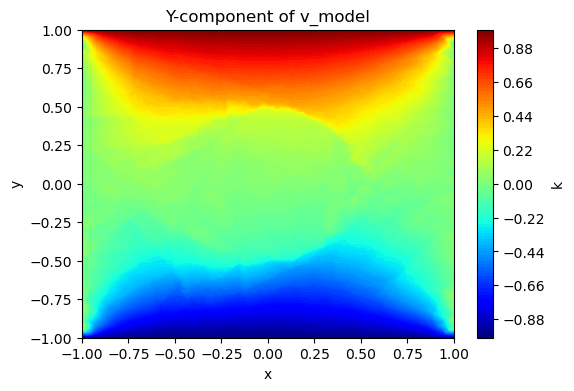

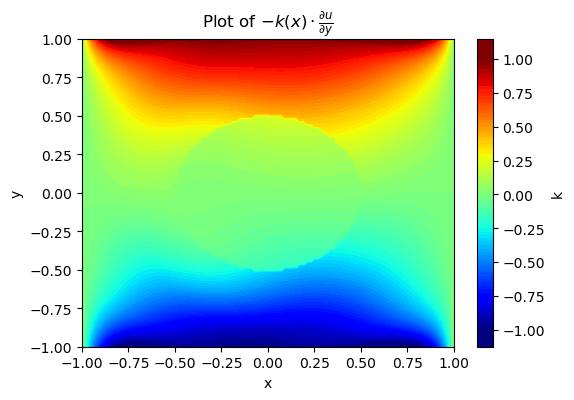

In [ ]:
def u_y_helper(x):
    x.requires_grad_(True)
    
    u = model_combined(x)[:, 0]
    u_y = grad(u, x, torch.ones_like(u))[0][:, 1]
                
    return u_y

plot_ctx.vmax = 0.01
plot_ctx.vmin = -0
plot_ctx.titles = [r"Comparing v_y with gradient $\frac{\partial u}{\partial y}$"]

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(k(x)[:, -1] * u_y_helper(x) + model_combined(x)[:, 2]), 0.0, 0.01)], plot_ctx)

plot_ctx.vmax = 1
plot_ctx.vmin = -1
plot_ctx.titles = ["Y-component of v_model"]

utils.plot_function_on_2d_cube([lambda x: model_combined(x)[:, 2]], plot_ctx)

plot_ctx.vmax = 1
plot_ctx.vmin = -1
plot_ctx.titles = [r"Plot of $-k(x)\cdot\frac{\partial u}{\partial y}$"]

utils.plot_function_on_2d_cube([lambda x: -k(x)[:, -1] * u_y_helper(x)], plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


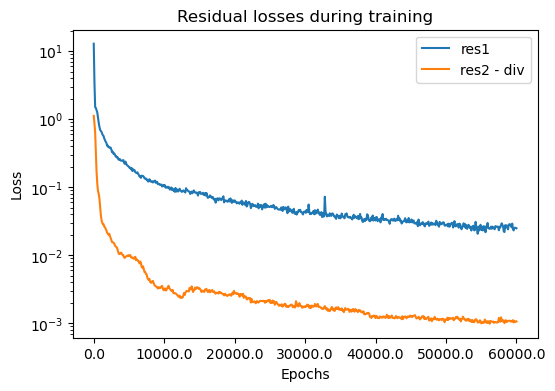

In [13]:
plot_ctx.titles = ['Residual losses during training']
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'
utils.plot_loss_values({"res1": combined_loss_comps[0],
                        "res2 - div": combined_loss_comps[1]}, plot_ctx)

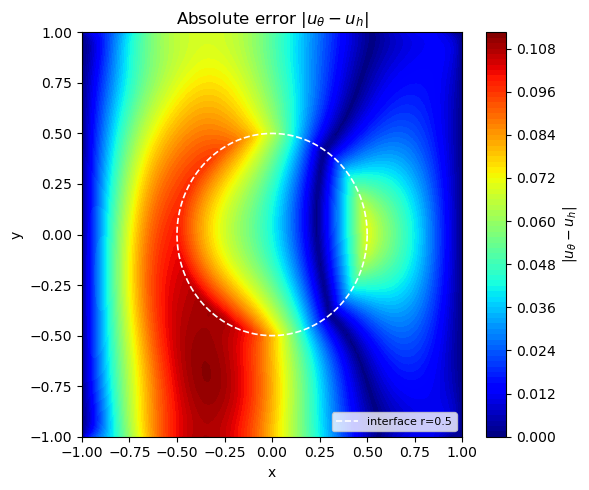

Mean absolute error : 4.6653e-02
Max  absolute error : 1.1116e-01
L2   relative error : 1.2348e-01


In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ── Load FEM reference solution ───────────────────────────────────────────
with h5py.File("darcy_solution.h5", "r") as f:
    xy_np = f["samples/xy"][:]         # (N, 2)
    u_fem = f["samples/u_interp"][:]   # (N,)

xy_fem  = torch.tensor(xy_np, dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem, dtype=torch.float32, device=device)

# ── Evaluate model_combined at the same points ────────────────────────────
model_combined.eval()
with torch.no_grad():
    u_pinn = model_combined(xy_fem)[:, 0]   # (N,)

# ── Absolute difference ───────────────────────────────────────────────────
abs_err = (u_pinn - u_fem_t).abs().cpu().numpy()

# ── Reconstruct grid ──────────────────────────────────────────────────────
xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)

X   = xy_np[:, 0].reshape(nx, ny)
Y   = xy_np[:, 1].reshape(nx, ny)
Err = abs_err.reshape(nx, ny)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(X, Y, Err, levels=100, cmap='jet')
fig.colorbar(cf, ax=ax, label=r'$|u_\theta - u_h|$')

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(0.5 * np.cos(theta), 0.5 * np.sin(theta), 'w--', linewidth=1.2, label='interface r=0.5')
ax.legend(fontsize=8, loc='lower right')

ax.set_title(r'Absolute error $|u_\theta - u_h|$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

print(f"Mean absolute error : {abs_err.mean():.4e}")
print(f"Max  absolute error : {abs_err.max():.4e}")
print(f"L2   relative error : {np.linalg.norm(abs_err) / np.linalg.norm(u_fem):.4e}")
